---
title: Buildings A and B Transfer Beams
project: Beaverton Creak Apartments
location: Beaverton, OR
client: GBD Architects
job_number: 10022500446
author:
  name: Andy Sazima
  initials: AGS
  email: andy.sazima@kpff.com
---

In [ ]:
%reset -f
import math
import os
import warnings
from collections.abc import Callable
from math import pow, sqrt

import forallpeople as units
import handcalcs
import handcalcs.render
import numpy as np

# import polars as pl
import pandas as pd
import sympy as sp
from Pynite import FEModel3D
from structural_tools.notebook.display import display_table, display_text, sig_figs, display_math
from structural_tools.notebook.calculation import check_value, set_params_columns, feet_inches as fi
from structural_tools.steel import calculate_critical_stress
from copy import deepcopy

from Pynite import FEModel3D
from steelpy import aisc

In [2]:
units.environment(env_name="structural", top_level=True)
handcalcs.set_option("custom_symbols", {"__": ",", "plus": "+", "minus": "-"})
handcalcs.set_option("greek_exclusions", ["psi"])
handcalcs.set_option("display_precision", 4)
handcalcs.set_option("param_columns", 1)
handcalcs.set_option("latex_block_start", "\\begin{equation*}")
handcalcs.set_option("latex_block_end", "\\end{equation*}")

In [ ]:
GENERATE_NEW_IMAGES = False

# Loading

We have the following loading conditions:

In [6]:
set_params_columns(6)

In [7]:
%%render params
DL = 28.5 * psf
LL = 40 * psf

<IPython.core.display.Latex object>

Since we are designing interior beams, live load reduction according to ASCE 7 Section 4.7 will apply. Each beam will have a different reduction factor, but the following applies:

1. Interior beam $\rightarrow K_{LL} = 2$ (ASCE 7 Table 4.7-1)
2. The transfer beams all support at least 2 floors $\rightarrow L_{red} \geq 0.4 L_o = L_{red,limit}$ (ASCE 7 Sec. 4.7.2)

In [8]:
K_LL = 2
L_red__limit = 0.4 * LL

We will assume that the top flanges are fully braced by the floor (no LTB).

# North-South beam at A-7.5 & A-A

We will first try to design this beam with a single span. If that does not work, we will use 2 spans with a post in the center wall. \autoref{fig:tb_a_1.png}


![Tributary diagram of the beam in question](images/tb_a_1.png){width=50% #fig:tb_a_1}

## Beam design

The beam loading and geometry are as follows

In [9]:
%%render
w_trib = fi(25, 7) / 2 * ft
l_trib = fi(19, 7) * ft
n_levels = 3

<IPython.core.display.Latex object>

In [10]:
%%render
A_trib = w_trib * l_trib * n_levels

<IPython.core.display.Latex object>

We can check if the live load can be reduced.

In [11]:
%%render
# fmt: off
if A_trib * K_LL >= 400 * ft * ft: L_red = LL * (0.25 + 15 / sqrt(K_LL * A_trib))
else: L_red = LL


<IPython.core.display.Latex object>

In [12]:
%%render
# fmt: off
if L_red >= L_red__limit: L_red = L_red
else: L_red = L_red__limit

<IPython.core.display.Latex object>

The beam at A-7.5 and A-A resolves the load from levels 2, 3, and 4 (not the roof); therefore, the load combinations are as follows:

Strength

1. $1.4 D$
2. $1.2 D + 1.6 L$

Service

1. $L$

This means the load cases are:

In [13]:
%%render params
D = DL
L = L_red

<IPython.core.display.Latex object>

In [14]:
%%render
D_line = D * w_trib
L_line = L * w_trib

<IPython.core.display.Latex object>

There is also dead load from the interior walls directly on top of the beam.

In [15]:
%%render
W_wall = 10 * psf
h_wall = 10.5 * ft
D_wall = W_wall * h_wall

<IPython.core.display.Latex object>

Along with the self weight of the beam, which will be automatically incorporated in the analysis.

In [16]:
# Initialize FE Model
base_model = FEModel3D()

# Materials
E = 29000  # Modulus of elasticity (ksi)
Fy = 50  # Yield stress (ksi)
nu = 0.3  # Poisson's ratio
G = E / (2 * (1 + nu))  # Shear modulus of elasticity (ksi)
rho = 489 / (12**3) / 1000  # Density (kci)
steel = base_model.add_material(name="steel", E=E, G=G, nu=nu, rho=rho, fy=Fy)

# Load combinations
base_model.add_load_combo("1.4D", {"D": 1.4}, ["strength"])
base_model.add_load_combo("1.2D+1.6L", {"D": 1.2, "L": 1.6}, ["strength"])
base_model.add_load_combo("L", {"L": 1}, ["service"])


In [17]:
tb_1_steel = deepcopy(base_model)

# Nodes
tb_1_steel.add_node("n1", 0, 0, 0)
tb_1_steel.add_node("n2", float(l_trib.to("inch")), 0, 0)

# Wide flange shape
wf = aisc.W_shapes.W14X26
display_text(f"Try a {wf.name}")

# Add a section with the following properties:
tb_1_steel.add_section(
    "wf",
    A=wf.area,
    Iy=wf.Iy,
    Iz=wf.Ix,
    J=wf.J,
)

# Add a member
tb_1_steel.add_member("m1", "n1", "n2", "steel", "wf")

# Provide simple supports
tb_1_steel.def_support("n1", True, True, True, False, False, False)
tb_1_steel.def_support("n2", False, True, True, True, False, False)

# Uniform loads
total_dead_load = n_levels * float(D_line) / 1000 / 12  # kip/in
tb_1_steel.add_member_dist_load("m1", "Fy", -total_dead_load, -total_dead_load, case="D")

wall_dead_load = n_levels * float(D_wall) / 1000 / 12  # kip/in
l_wall_1 = fi(6, 6, return_unit="in")
l_wall_2 = fi(3, 9, return_unit="in")
l_wall_3 = fi(3, 4, return_unit="in")
l_gap_1_2 = fi(3, 4, return_unit="in")
l_gap_2_3 = fi(2, 8, return_unit="in")
x0 = 0
x1 = l_wall_1
x2 = l_wall_1 + l_gap_1_2
x3 = l_wall_1 + l_gap_1_2 + l_wall_2
x4 = l_wall_1 + l_gap_1_2 + l_wall_2 + l_gap_2_3
x5 = l_wall_1 + l_gap_1_2 + l_wall_2 + l_gap_2_3 + l_wall_3
tb_1_steel.add_member_dist_load(
    "m1",
    "Fy",
    -wall_dead_load,
    -wall_dead_load,
    x1=x0,
    x2=x1,
    case="D",
)
tb_1_steel.add_member_dist_load(
    "m1",
    "Fy",
    -wall_dead_load,
    -wall_dead_load,
    x1=x2,
    x2=x3,
    case="D",
)
tb_1_steel.add_member_dist_load(
    "m1",
    "Fy",
    -wall_dead_load,
    -wall_dead_load,
    x1=x4,
    x2=x5,
    case="D",
)

tb_1_steel.add_member_self_weight("FY", -1, case="D")

total_live_load = n_levels * float(L_line) / 1000 / 12  # kip/in
tb_1_steel.add_member_dist_load("m1", "Fy", -total_live_load, -total_live_load, case="L")

# Analyze the beam
tb_1_steel.analyze()

'Try a W14X26'

In [18]:
if GENERATE_NEW_IMAGES:
    # from Pynite.Rendering import Renderer  # or Pynite.Visualization
    from Pynite.Visualization import Renderer  # or Pynite.Visualization
    import vtk

    # Create renderer
    renderer = Renderer(tb_1_steel)

    for combo_name in base_model.load_combos.keys():
        renderer.combo_name = combo_name
        renderer.window.SetSize(1920, 540)

        renderer.theme = "print"
        renderer.annotation_size = 3
        renderer.update()
        renderer.renderer.ResetCamera()
        camera = renderer.renderer.GetActiveCamera()
        camera.Zoom(3.25)
        actors = renderer.renderer.GetActors()
        actors.InitTraversal()
        for i in range(0, actors.GetNumberOfItems()):
            actor = actors.GetNextActor()
            if i >= 4:
                if actor.GetClassName() == "vtkFollower":
                    actor.GetProperty().SetColor(0, 0.75, 0)  # red labels
        renderer.window.Render()

        w2if = vtk.vtkWindowToImageFilter()
        w2if.SetInput(renderer.window)
        w2if.SetInputBufferTypeToRGB()
        w2if.ReadFrontBufferOff()

        writer = vtk.vtkPNGWriter()
        writer.SetInputConnection(w2if.GetOutputPort())
        writer.SetFileName(f"images/tb_1_steel_loading_{combo_name}.png")
        writer.Write()

        # Now that we're done with the render window, finalize it
        renderer.window.Finalize()

    # Save result
    # renderer.screenshot("images/tb_1_steel_loading.png", interact=False, reset_camera=False)

We will first try to design this beam with a single span. See \autoref{fig:tb_a_1_loading_14D} through \autoref{fig:tb_a_1_loading_L}.

- Note that all units are in kips and inches.

![Loading of the beam in question](images/tb_1_steel_loading_1.4D.png){width=100% #fig:tb_a_1_loading_14D}
![Loading of the beam in question](images/tb_1_steel_loading_1.2D+1.6L.png){width=100% #fig:tb_a_1_loading_12D16L}
![Loading of the beam in question](images/tb_1_steel_loading_L.png){width=100% #fig:tb_a_1_loading_L}

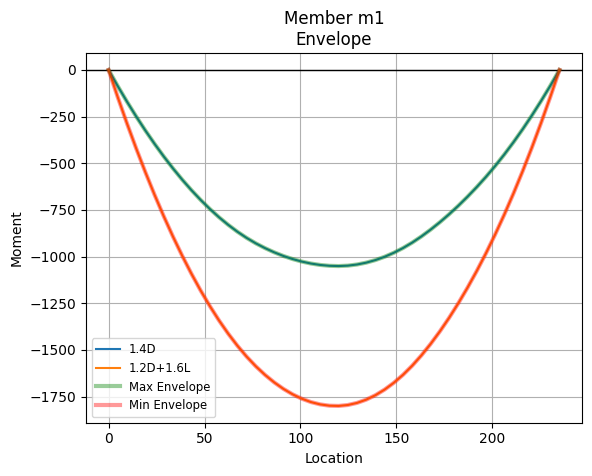

In [19]:
tb_1_steel.members["m1"].plot_moment("Mz", ["strength"], 50)
M_dem, _ = tb_1_steel.members["m1"].min_moment("Mz", ["strength"])
M_dem = M_dem * -1 * kip * inch
M_dem__kipft = M_dem * 1 * ft / 12 / inch * kip

Moment demands are:

In [20]:
display_math([
    "M_{dem} &= " + str(sig_figs(M_dem, 3)) + "\\textrm{ kip-in}",
    "M_{dem,kipft} &= " + str(sig_figs(M_dem__kipft, 3)) + "\\textrm{ kip-ft}",
])

['M_{dem} &= 1800\\textrm{ kip-in}', 'M_{dem,kipft} &= 150\\textrm{ kip-ft}']

We will check the maximum bending moment from strength-based load combinations against the strength-based moment capacity.

In [21]:
%%render params
phi_b = 0.9
F_y = base_model.materials["steel"].fy * ksi
Z_x = wf.Zx * inch**3

<IPython.core.display.Latex object>

In [22]:
%%render
M_cap = phi_b * F_y * Z_x
M_cap__kipft = M_cap * 1 * ft / (12 * inch)

<IPython.core.display.Latex object>

In [23]:
%%render
DCR = M_dem / M_cap
check_DCR = check_value(DCR, 1, "<=")

<IPython.core.display.Latex object>

We will also check deflection against a limit of $l/360$ as it is the governing case for this beam that supports both the floor and ceiling on level 2.

In [24]:
delta_L_val = tb_1_steel.members["m1"].min_deflection("dy", "L")

In [25]:
%%render long
# fmt: off
delta_L = (delta_L_val * inch * -1)
delta_max__L = l_trib.to("inch") / 360
check_delta__L = check_value(delta_L, delta_max__L)

<IPython.core.display.Latex object>

## Post Design

### 6x6 Timber Post

We will now want to check that the 6x6 wood posts are adequate.

The design assumptions we will use are:

1. non-eccentric loading
2. Douglas Fir No. 1
3. Dry

The loading stress on the post, $f_c$, is

In [26]:
max_reaction = max([
    abs(tb_1_steel.nodes[node].RxnFY[combo])
    for node in tb_1_steel.nodes.keys()
    for combo in tb_1_steel.load_combos.keys()
])

In [27]:
%%render
b = 5.5 * inch
d = 5.5 * inch
A = b * d
P = max_reaction * kip
f_c = P / A


<IPython.core.display.Latex object>

In [28]:
set_params_columns(3)

We must adjust the design compressive value, $F_c$

In [29]:
%%render params
C_D = 1.0
C_M = 1.0
C_t = 1.0
C_F = 1.0
C_i = 1.0
C_fu = 1.0
C_T = 1.0

F_c = 1000 * psi
E_min = 580_000 * psi

<IPython.core.display.Latex object>

The column stability factor, $C_P$, is

In [30]:
%%render
F_star_C = F_c * C_D * C_M * C_t * C_F * C_i
E_prime_min = E_min * C_M * C_t * C_fu * C_i * C_T

<IPython.core.display.Latex object>

In [31]:
%%render
c = 0.8  # sawn lumber
h_level_1 = 11.5 * ft
K_e = 1  # pinned ends
l_e = K_e * h_level_1
check_le__d = check_value(l_e / d, 50, "<=")
F_cE = (0.822 * E_prime_min) / (l_e / d) ** 2

<IPython.core.display.Latex object>

In [32]:
C_P = (1 + (F_cE / F_star_C)) / (2 * c) - sqrt(((1 + (F_cE / F_star_C)) / (2 * c)) ** 2 - (F_cE / F_star_C) / c)

The fully adjusted compressive design value is

In [33]:
%%render
F_prime_C = F_star_C * C_P

<IPython.core.display.Latex object>

In [34]:
%%render
check_compression = check_value(f_c, F_prime_C, "<=")

<IPython.core.display.Latex object>

In [35]:
if "NG" in check_compression:
    display_text("A 6x6 post will not work--we need to use HSS")

'A 6x6 post will not work--we need to use HSS'

### HSS Post

The following \autoref{tab:hss_capacities} values are the reference design compression capacities of various HSS posts that could be used in this project.

In [ ]:
hss_shape_list = [
    "HSS3_1_2X3_1_2X1_8",
    "HSS4X4X1_8",
    "HSS4X4X3_16",
    "HSS4X4X1_4",
    "HSS4_1_2X4_1_2X1_4",
    "HSS5X5X1_4",
    "HSS5X5X5_16",
    "HSS5X5X3_8",
]
capacities = pd.DataFrame({}, index=hss_shape_list)
capacities.index.name = "Shape"
K = 1.0
L_c = float(h_level_1.to("inch") * K)
L_c = 10.75 * 12
E = 29000
F_y = 50
phi_c = 0.9
for shape in hss_shape_list:
    hss = aisc.HSS_shapes.sections[shape]
    r = hss.rx
    A = hss.area
    F_cr = calculate_critical_stress(yield_stress=F_y, youngs_modulus=E, effective_length=L_c, radius_of_gyration=r)
    capacities.loc[shape, "adjusted capacity"] = phi_c * F_cr * A
    capacities.loc[shape, "radius of gyration"] = r
    capacities.loc[shape, "gross area"] = A
    capacities.loc[shape, "slenderness ratio"] = L_c / r
    capacities.loc[shape, "critical buckling stress"] = F_cr

column_name_map = {"adjusted capacity": r"$\phi_c P_n$ [kip]"}
display_table(
    dataframe=capacities,
    column_names_filter_and_map=column_name_map,
    position_float="centering",
    caption="Common HSS shape capacities",
    label="tab:hss_capacities",
)

NameError: name 'F_e' is not defined

In [ ]:
minimum_viable_shape = capacities.loc[capacities["adjusted capacity"] >= max_reaction, "adjusted capacity"].idxmin()
minimum_viable_capacity = capacities.loc[capacities["adjusted capacity"] >= max_reaction, "adjusted capacity"].min()
display_text(rf"The minimum viable HSS shape is {minimum_viable_shape}")
display_math([
    rf"P_u = {sig_figs(max_reaction, 3)} \text{{ kip}}",
    rf"\phi_c P_n = {sig_figs(minimum_viable_capacity, 3)} \text{{ kip}}",
])

'The minimum viable HSS shape is HSS3_1_2X3_1_2X1_8'